I worked on this assignment alone. Here is the link to my repository :
https://github.com/ouissamena/MAM2ADMM-Series00-Git-ouissamena


We start by importing different libraries. "pandas" to read CSV files, numpy to process the data and matplotlib.pyplot to generate graphs. The we load the data using a pandas already existing fuction.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("0_z.csv")
df.columns = ["t", "x", "y", "z"]

Then we compute the ENMO data.

In [66]:
df["enmo"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2) - 1

The next step is to create a function to aggregated by epoch.

In [67]:
def integrate_enmo(df, epoch_length):
    df_epoch = df.copy()
    df_epoch["epoch"] = (df_epoch["t"] // epoch_length).astype(int)
    integrated = df_epoch.groupby("epoch")["enmo"].sum().reset_index()
    integrated["time"] = integrated["epoch"] * epoch_length
    return integrated

The data is integrated for different lenghs and the bar histograms are created usinge matplotlib.pyplot functions. Th raw data is also presented in a graph.

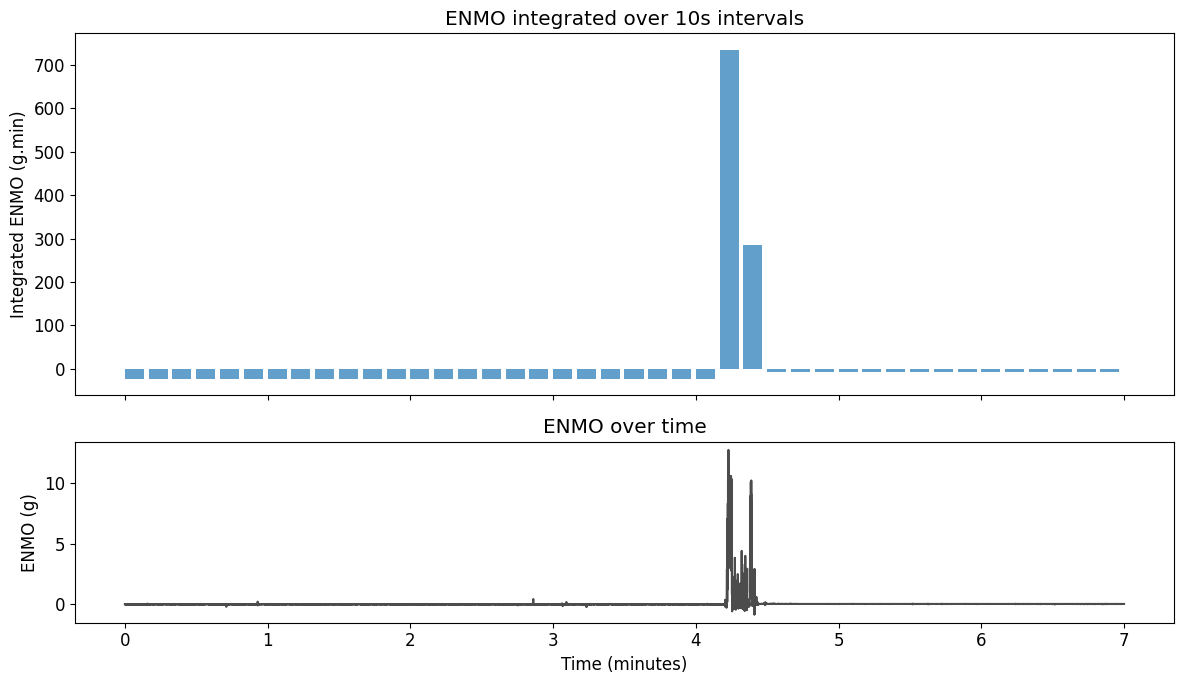

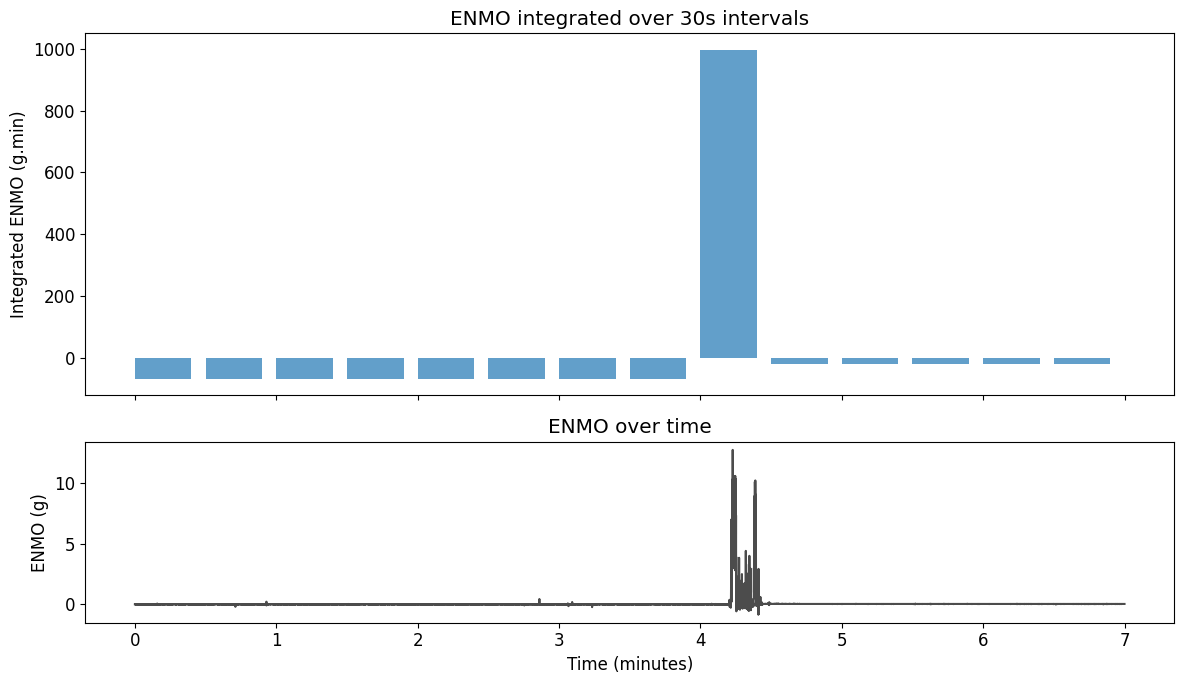

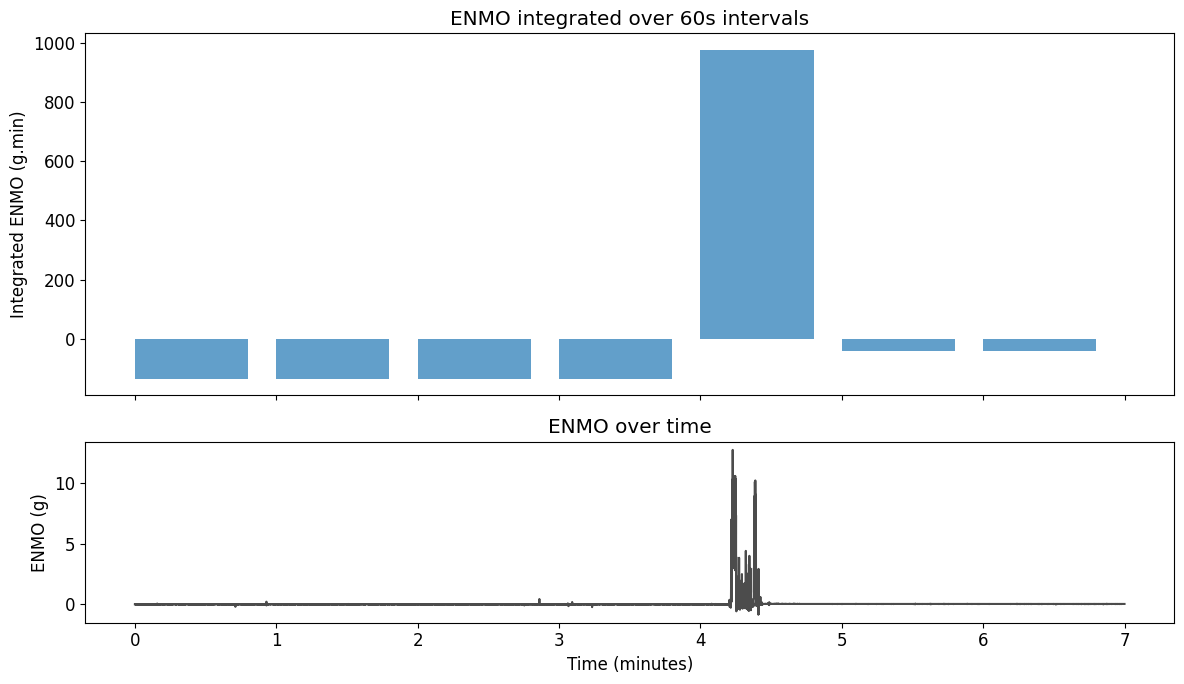

In [68]:
# --- Integration for several epoch lengths ---
epochs = [10, 30, 60]
results = {ep: integrate_enmo(df, ep) for ep in epochs}

# --- For each epoch, plot integrated ENMO and raw ENMO below ---
for ep in epochs:
    d = results[ep]
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    # Bar plot for integrated ENMO
    bar_width = ep * 0.8
    axes[0].bar(d["time"] / 60, d["enmo"], width=bar_width / 60, align='edge', alpha=0.7, )
    axes[0].set_ylabel("Integrated ENMO (g.min)")
    axes[0].set_title(f"ENMO integrated over {ep}s intervals")
    # Raw ENMO over time (x-axis in minutes)
    axes[1].plot(df["t"] / 60, df["enmo"], color="black", alpha=0.7)
    axes[1].set_xlabel("Time (minutes)")
    axes[1].set_ylabel("ENMO (g)")
    axes[1].set_title("ENMO over time")
    plt.tight_layout()
    plt.show()